# ML con Datos Meteorologicos

En este notebook estudiamos el efecto de los datos meteorologicos en la cantidad de pasajeros, por horas.

In [28]:
import requests
import pandas as pd
import numpy as np
import seaborn as sns

## 1. Datos Meteorologicos

Usamos el API de [open-meteo](https://open-meteo.com/) para descargar los datos meteorologicos.

In [29]:
fields = ["pm2_5", "apparent_temperature", "relative_humidity_2m"]
start_date = "2025-04-21"
end_date = "2025-04-27"

air_api = f"https://air-quality-api.open-meteo.com/v1/air-quality?latitude=-33.45694&longitude=-70.64827&start_date={start_date}&end_date={end_date}&hourly={fields[0]}&timezone=America/Santiago"
meteo_json_api = f"https://archive-api.open-meteo.com/v1/archive?latitude=-33.45694&longitude=-70.64827&start_date={start_date}&end_date={end_date}&hourly={",".join(fields[1:])}&timezone=America/Santiago"

air_quality_json = requests.get(air_api).json()
meteo_json = requests.get(meteo_json_api).json()

In [30]:
# Guardar los datos meteos
import json

with open("../data/meteo/air_quality.json", "w", encoding="utf-8") as f:
    json.dump(air_quality_json, f, indent=4)
with open("../data/meteo/meteo.json", "w", encoding="utf-8") as f:
    json.dump(meteo_json, f, indent=4)

In [31]:
meteo_df = pd.concat(
    [
        pd.json_normalize(air_quality_json["hourly"], record_path=["time"]),
        pd.json_normalize(air_quality_json["hourly"], record_path=["pm2_5"]),
        *[pd.json_normalize(meteo_json["hourly"], record_path=[field]) for field in fields[1:]]
    ], axis=1
)
meteo_df.columns = ["time", *fields]
meteo_df.tail()

,time,pm2_5,apparent_temperature,relative_humidity_2m
163,2025-04-27T19:00,42.6,19.5,58
164,2025-04-27T20:00,58.2,18.1,63
165,2025-04-27T21:00,69.6,17.9,62
166,2025-04-27T22:00,70.5,16.7,65
167,2025-04-27T23:00,71.7,16.1,67


In [32]:
meteo_df["time"] = pd.to_datetime(meteo_df["time"])
meteo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  168 non-null    datetime64[ns]
 1   pm2_5                 168 non-null    float64       
 2   apparent_temperature  168 non-null    float64       
 3   relative_humidity_2m  168 non-null    int64         
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 5.4 KB


In [33]:
meteo_df.tail()

,time,pm2_5,apparent_temperature,relative_humidity_2m
163,2025-04-27 19:00:00,42.6,19.5,58
164,2025-04-27 20:00:00,58.2,18.1,63
165,2025-04-27 21:00:00,69.6,17.9,62
166,2025-04-27 22:00:00,70.5,16.7,65
167,2025-04-27 23:00:00,71.7,16.1,67


## 2. Datos sobre Cantidad de Pasajeros

Cargamos el dataframe procesado usando el scrit [datos_por_hora](./script/datos_por_hora.ipynb).

In [34]:
pasaj_df = pd.read_csv("../data/pasajeros_por_hora.csv")
pasaj_df.tail()

,hora,2025-04-21,2025-04-22,2025-04-23,2025-04-24,2025-04-25,2025-04-26,2025-04-27
19,19,304,326,320,335,272,339,409
20,20,200,203,186,206,202,256,369
21,21,101,139,144,134,145,198,229
22,22,77,66,65,87,93,120,113
23,23,9,11,14,17,19,23,10


In [35]:
pasajes = []
for col in pasaj_df.columns[1:]:
    pasajes.extend(pasaj_df[col].values.tolist())
pasajs = np.array(pasajes)

In [36]:
pasajs_mean = pasajs.mean()

## 3. Dataframe Completo

Armamos un dataframe que contiene los datos anteriores, para poder hacer los siguiente analisis.

In [37]:
full_df = meteo_df.copy()
full_df["pasaj"] = pasajs
full_df["hora"] = full_df["time"].dt.hour

full_df.tail()

,time,pm2_5,apparent_temperature,relative_humidity_2m,pasaj,hora
163,2025-04-27 19:00:00,42.6,19.5,58,409,19
164,2025-04-27 20:00:00,58.2,18.1,63,369,20
165,2025-04-27 21:00:00,69.6,17.9,62,229,21
166,2025-04-27 22:00:00,70.5,16.7,65,113,22
167,2025-04-27 23:00:00,71.7,16.1,67,10,23


## 4. Explorar sobre los datos

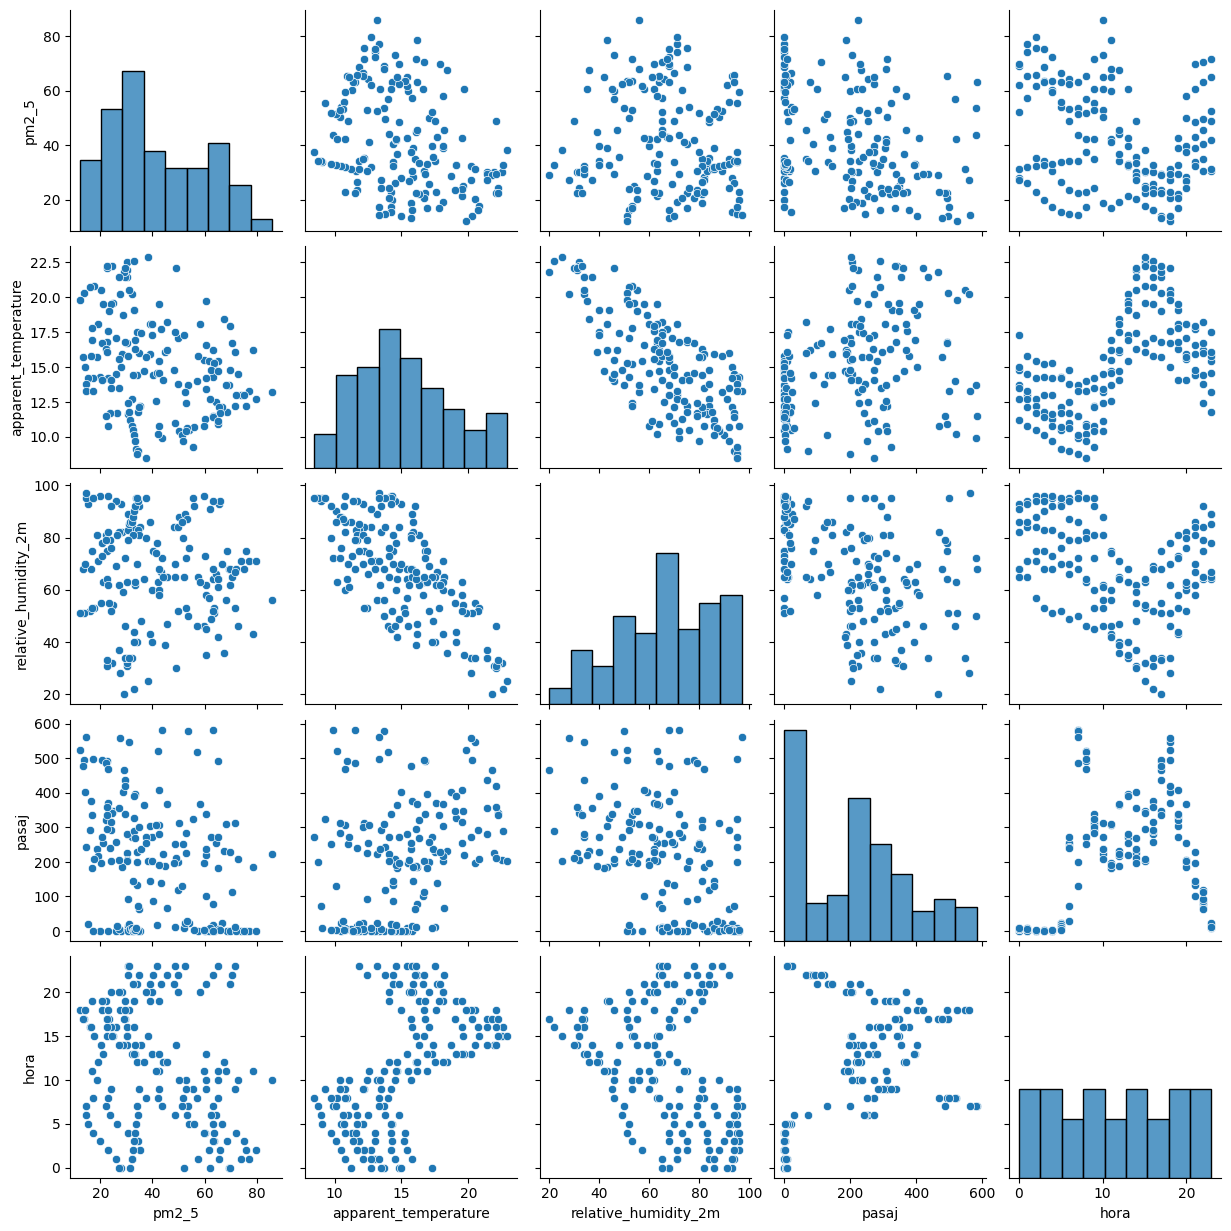

In [38]:
sns.pairplot(full_df)

<Axes: >

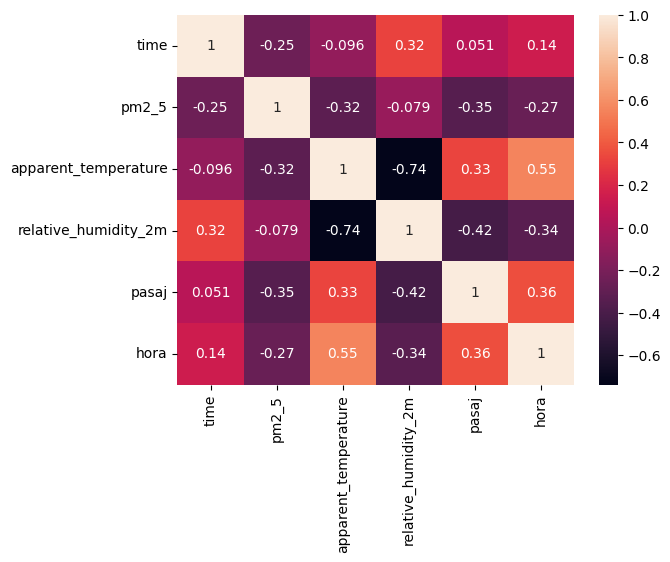

In [39]:
sns.heatmap(full_df.corr(), annot=True)

## 5. Regresion


A partir de las exploraciones anteriores, generamos una hipotesis de que la cantidad de pasajero esta relacionada con `pm2_5`, `apparent_temperature`, `relative_humidity_2m`.

Es decir:

$$\text{pasaj} \approx \alpha_0 + \alpha_1\text{pm2\_5} + \alpha_2\text{temp} + \alpha_3\text{humid} $$

Entonces vamos a crear un modelo de regresion lineal, usando estas como variables independientes para predecir la cantidad de pasajero.

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt

In [41]:
def metricas(y_test, y_pred):
    # RMSE
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    print(f"Raíz del Error Cuadrático Medio (RMSE) en datos de Test: {rmse:.2f}")

    # MAE
    mae = metrics.mean_absolute_error(y_test, y_pred)
    print(f"Mean Absolute Error (MAE) en datos de Test: {mae:.2f}")

    # R2
    r2 = metrics.r2_score(y_test, y_pred)
    print(f"Coeficiente R^2 en datos de Test: {r2:.2f}")

In [42]:
variables = ["pm2_5", "apparent_temperature", "relative_humidity_2m"]
X = full_df[variables]
y = full_df["pasaj"]

In [43]:
# Separar train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [44]:
# Normalizar
sc = StandardScaler()

X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [45]:
# crear modelo de regresion lineal
modelo_regresion = LinearRegression()
modelo_regresion.fit(X_train, y_train)

y_pred = modelo_regresion.predict(X_test)

metricas(y_test, y_pred)

Raíz del Error Cuadrático Medio (RMSE) en datos de Test: 143.50
Mean Absolute Error (MAE) en datos de Test: 108.86
Coeficiente R^2 en datos de Test: 0.36


In [46]:
print(round(143.50 / pasajs_mean, 2))

0.69


Se note que el valor predicido tiene un RMSE de 144 (i.e. una diferencia de 69% comparando con el promedio de dato reale), y un R2 de 0.36, concluimos que el modelo no es muy efecticvo.

Veamos la ecuacion.

In [47]:
"pasaje = {} + {}*pm2_5 + {}*temp + {}*humid".format(
    round(modelo_regresion.intercept_, 2),
    *modelo_regresion.coef_.round(2)
)

'pasaje = 1167.67 + -5.29*pm2_5 + -21.1*temp + -6.41*humid'

Veamos el efectos de cada variable.

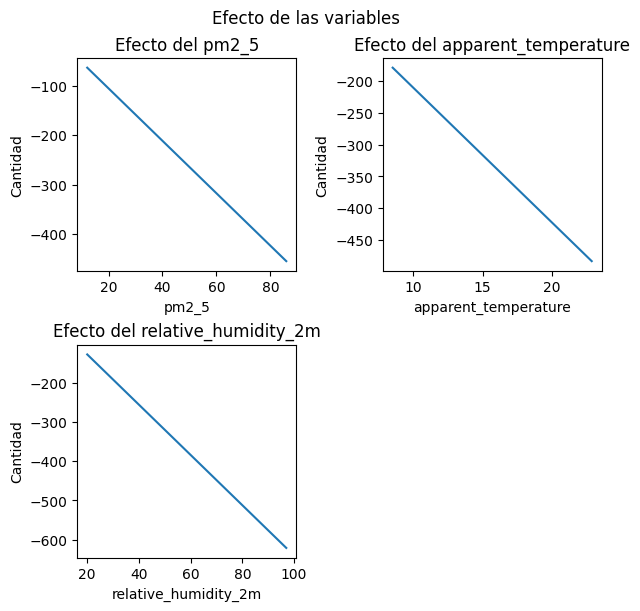

In [48]:
fig = plt.figure(figsize=(6,6), constrained_layout=True)
fig.suptitle("Efecto de las variables")

for i in range(3):
    v = variables[i]
    coef = modelo_regresion.coef_[i]
    ax = fig.add_subplot(220 + i+1)
    ax.set_title(f"Efecto del {v}")

    x = np.arange(X[v].min(), X[v].max(), 0.01)
    y = coef*x
    ax.plot(x, y, label=v)

    ax.set_ylabel('Cantidad',fontsize=10)
    ax.set_xlabel(v, fontsize=10)

Comparamos la variable dependiente real con la predicido, queremos que los puntos estan cerca de identidad (y=x).

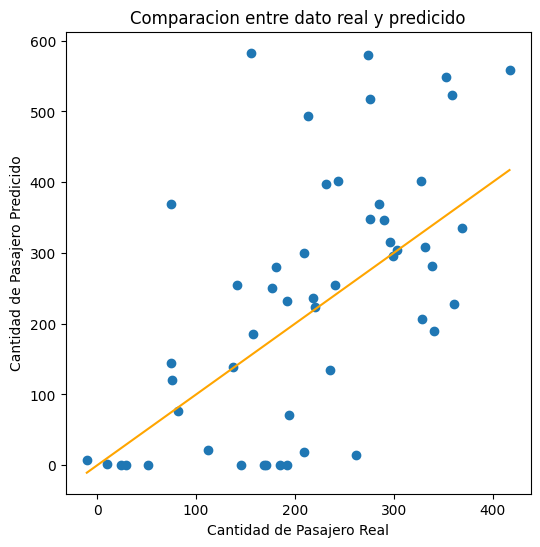

In [49]:
plt.figure(figsize=(6,6))

plt.scatter(y_pred, y_test)

line = np.arange(y_pred.min(), y_pred.max(), 0.01)
plt.plot(line, line, color="orange", )

plt.ylabel('Cantidad de Pasajero Predicido')
plt.xlabel('Cantidad de Pasajero Real')
plt.title('Comparacion entre dato real y predicido')
plt.show()

Se nota que no todos los puntos esta cerca de la identidad, hay muchas excepciones.